# Overall settings

In [203]:
from lxd_io import Dataset
import matplotlib.pyplot as plt
import numpy as np

dataset_path = "/home/hendrik/data/highD-dataset-v1.0"
dataset = Dataset(dataset_path)

C_EGO = '#8080ff'
C_OBJ = '#ff8080'
C_OTH = '#803dc0'

t_fields = ['frame', 'x', 'y', 'xVelocity', 'yVelocity']

2025-06-09 00:09:27.684 | DEBUG    | lxd_io.dataset:__init__:49 - Read dataset highd-1.0 from: /home/hendrik/data/highD-dataset-v1.0
2025-06-09 00:09:27.685 | DEBUG    | lxd_io.dataset:_explore_data_dir:175 - Search for recordings in: /home/hendrik/data/highD-dataset-v1.0/data
2025-06-09 00:09:27.708 | DEBUG    | lxd_io.dataset:_explore_data_dir:254 - Found complete data for 60 recordings:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
2025-06-09 00:09:27.709 | DEBUG    | lxd_io.dataset:_explore_maps_dir:261 - Search for maps in: /home/hendrik/data/highD-dataset-v1.0/maps
2025-06-09 00:09:27.710 | WARNING  | lxd_io.dataset:_explore_maps_dir:272 - No Lanelet2 map directories found.
2025-06-09 00:09:27.712 | WARNING  | lxd_io.dataset:_explore_maps_dir:289 - No OpenDrive map directories found.


# Which tracks?
- Load the recording and the track

In [204]:
recording = dataset.get_recording(12)

i_ego = 1115
i_objs = [1110, 1109, 1116]

2025-06-09 00:09:27.720 | DEBUG    | lxd_io.dataset:get_recording:371 - Get recording 12.
2025-06-09 00:09:27.722 | DEBUG    | lxd_io.recording:__init__:29 - Load csv files for recording 12.


# Get the relevant data

In [205]:
# Get data from track
# Ego
ego = {}
ego['t'] = recording.get_track(i_ego)
for field in t_fields:
    ego[field] = ego['t'].get_data(field)
    
# Objs
objs = []
for id in i_objs:
    obj = {}
    obj['t'] = recording.get_track(id)
    for field in t_fields:
        obj[field] = obj['t'].get_data(field)
        if field == 'frame':
            b_in = np.logical_and(obj['frame'] >= ego['frame'][0], obj['frame'] <= ego['frame'][-1])
        obj[field] = obj[field][b_in]
    objs.append(obj)

2025-06-09 00:09:27.738 | DEBUG    | lxd_io.recording:_read_tracks_file:62 - Load tracks file for recording 12


## Get the lane markings

In [206]:
if ego['t'].get_data('xVelocity')[0] < 0:
    lanes_raw = recording.get_meta_data('upperLaneMarkings')
else:
    lanes_raw = recording.get_meta_data('lowerLaneMarkings')

lanes = [float(x) for x in lanes_raw.split(";")]
print(lanes)


[7.92, 11.89, 15.69, 19.58]


In [207]:
ego['w2'] = -ego['t'].get_meta_data('width')/2 * np.sign(ego['t'].get_data('xVelocity')[0])
ego['h2'] = ego['t'].get_meta_data('height')/2

ego['xc'] = ego['x'] + ego['w2']
ego['yc'] = ego['y'] + ego['h2']

for obj in objs:
    obj['w2'] = -obj['t'].get_meta_data('width')/2 * np.sign(ego['t'].get_data('xVelocity')[0])
    obj['h2'] = obj['t'].get_meta_data('height')/2

    obj['xc'] = obj['x'] + ego['w2']
    obj['yc'] = obj['y'] + ego['h2']

# Plot in the road

2025-06-09 00:09:27.916 | DEBUG    | lxd_io.recording:_plot_multiple_tracks:244 - Plot recording 12, tracks [1116, 1109, 1110, 1115]


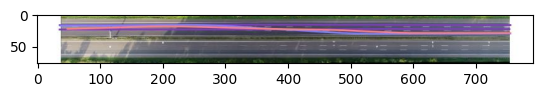

In [208]:
# Plot tracks ob road
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[C_OTH, C_OTH, C_EGO, C_OBJ])  # Custom color list
plot_file = recording.plot_track(i_objs[::-1] + [i_ego], ".")

im = plt.imread(plot_file)
plt.imshow(im)
plt.show()


# Plot the absolute trajectories

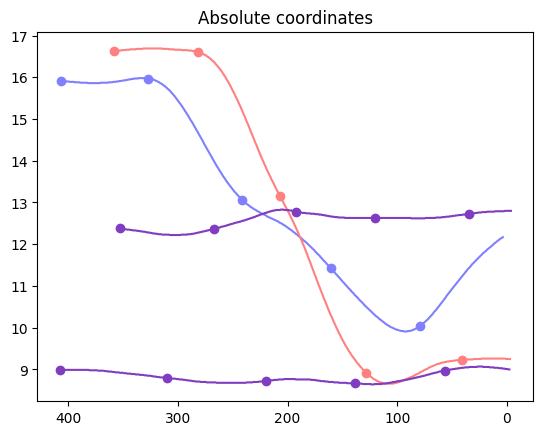

In [209]:
step = 100
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[C_EGO, C_OBJ, C_OTH, C_OTH])
l_e, = plt.plot(ego['x'], ego['y'])
plt.plot(ego['x'][::step], ego['y'][::step], 'o', color=l_e.get_color(), label='Markers')

for obj in objs:
    l_o, = plt.plot(obj['x'], obj['y'])
    plt.plot(obj['x'][::step], obj['y'][::step], 'o', color=l_o.get_color(), label='Markers')

if ego['t'].get_data('xVelocity')[0] < 0:
    plt.gca().invert_xaxis()
else:
    plt.gca().invert_yaxis()

plt.title('Absolute coordinates')

plt.show()

# Plot relative directories
_This is not really helpful..._

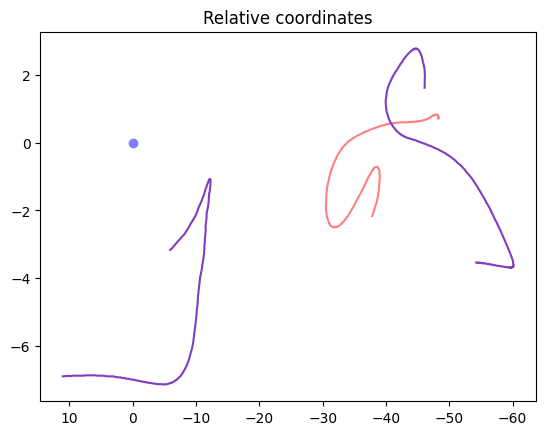

In [210]:
for obj in objs:
    # To get the matching pieces of the vecotors
    obj_in_ego = np.logical_and(obj['frame'] >= ego['frame'][0], obj['frame'] <= ego['frame'][-1])
    ego_in_obj = np.logical_and(ego['frame'] >= obj['frame'][0], ego['frame'] <= obj['frame'][-1])

    # Get the relative coordinates
    obj['x_rel'] = obj['x'][obj_in_ego] - ego['x'][ego_in_obj]
    obj['y_rel'] = obj['y'][obj_in_ego] - ego['y'][ego_in_obj]

    obj['x_in_ego'] = obj['x'][obj_in_ego]
    obj['y_in_ego'] = obj['y'][obj_in_ego]

plt.plot(0,0,'o')

for obj in objs:
    plt.plot(obj['x_rel'], obj['y_rel'])

if ego['t'].get_data('xVelocity')[0] < 0:
    plt.gca().invert_xaxis()
else:
    plt.gca().invert_yaxis()   

plt.title('Relative coordinates')

plt.show()

# Plot x-Relative trajectories
Just visualize the lane change, but still not really helpful...

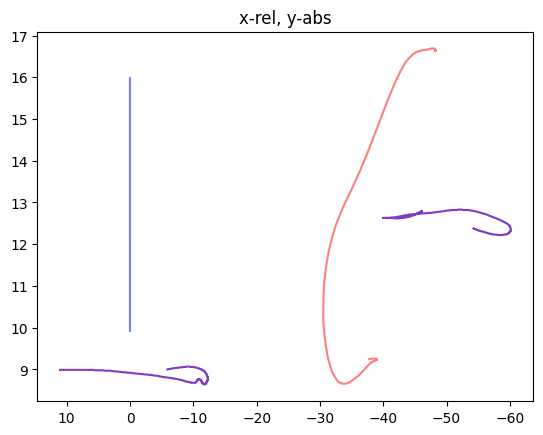

In [211]:
plt.plot(np.zeros(np.shape(ego['y'])), ego['y'])
for obj in objs:
    plt.plot(obj['x_rel'], obj['y_in_ego'])


if ego['t'].get_data('xVelocity')[0] < 0:
    plt.gca().invert_xaxis()
else:
    plt.gca().invert_yaxis()   

plt.title('x-rel, y-abs')

plt.show()

# Data at interesting frames
- $f_(init_{global})$ - First frame all objects have in common
- $f(end_{global})$ - Last frame all objects have in common
- $f(y_{max, ego})$ - Greatest y position of ego
- $f(y_{min, ego})$ - Smallest y position of ego
- $f(v_{y, min, ego})$ - Greatest y-velocity of ego

In [212]:
f_init_global = max([ego['frame'][0]] + [obj['frame'][0] for obj in objs])
f_end_global = min([ego['frame'][-1]] + [obj['frame'][-1] for obj in objs])

print(f"Ego frames: {ego['frame'][0]} - {ego['frame'][-1]}")
for i, obj in enumerate(objs):
    print(f"Obj-{i} frames: {obj['frame'][0]} - {obj['frame'][-1]}")

print(f"Global common timespan is: {f_init_global} - {f_end_global}")

# Other relevant points in time
ego['b_globT'] = np.logical_and(ego['frame'] >= f_init_global, ego['frame'] <= f_end_global)

f_ego_y_max = ego['frame'][ego['b_globT']][np.argmax(ego['y'][ego['b_globT']])]
f_ego_y_min = ego['frame'][ego['b_globT']][np.argmin(ego['y'][ego['b_globT']])]

print(f"Maximum ego y at {f_ego_y_max} with {ego['t'].get_data_at_frame('y', f_ego_y_max)}")
print(f"Minimum ego y at {f_ego_y_min} with {ego['t'].get_data_at_frame('y', f_ego_y_min)}")

f_ego_vy_max = ego['frame'][ego['b_globT']][np.argmax(np.abs(ego['yVelocity'][ego['b_globT']]))]
print(f"Maximum ego y-velocity at {f_ego_vy_max} with {ego['t'].get_data_at_frame('yVelocity', f_ego_vy_max)}")


Ego frames: 8746 - 9229
Obj-0 frames: 8746 - 9196
Obj-1 frames: 8746 - 9188
Obj-2 frames: 8759 - 9229
Global common timespan is: 8759 - 9188
Maximum ego y at 8835 with 15.98
Minimum ego y at 9129 with 9.91
Maximum ego y-velocity at 8902 with -1.0


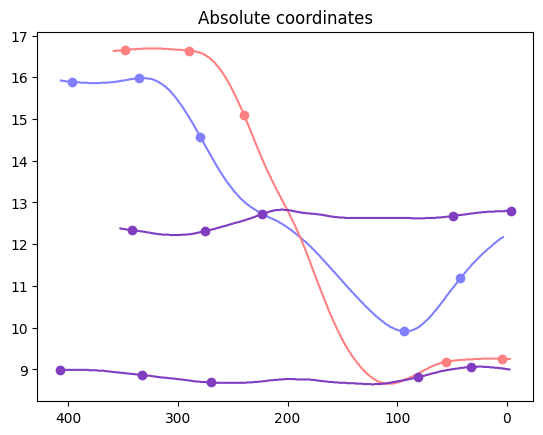

In [213]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[C_EGO, C_OBJ, C_OTH, C_OTH])
l_e, = plt.plot(ego['x'], ego['y'])

pois = [f_init_global, f_ego_y_max, f_ego_vy_max, f_ego_y_min, f_end_global]

for p in pois:
    plt.plot(ego['t'].get_data_at_frame('x', p), ego['t'].get_data_at_frame('y', p), 'o', color=l_e.get_color(), label='Markers')

for obj in objs:
    l_o, = plt.plot(obj['x'], obj['y'])
    for p in pois:
        plt.plot(obj['t'].get_data_at_frame('x', p), obj['t'].get_data_at_frame('y', p), 'o', color=l_o.get_color(), label='Markers')

if ego['t'].get_data('xVelocity')[0] < 0:
    plt.gca().invert_xaxis()
else:
    plt.gca().invert_yaxis()

plt.title('Absolute coordinates')

plt.show()

# Plot Bounding boxes

## All in one plot

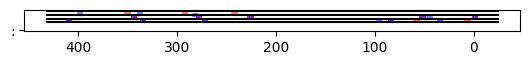

In [214]:
ego_bb = ego['t'].get_bbox_at_frame(f_init_global)

color_cycler = plt.rcParams['axes.prop_cycle']
cycle = color_cycler()
color = next(cycle)['color']

for i, p in enumerate(pois):
    bb = ego['t'].get_bbox_at_frame(p)[0]
    c = bb.mean(axis=0)
    bb = np.vstack([bb, bb[0]])
    x = ego['t'].get_data_at_frame('x',p)
    y = ego['t'].get_data_at_frame('y',p)
    plt.plot(bb[:, 0], bb[:, 1], color=color)
    # plt.text(c[0], c[1], str(i), fontsize=8, ha='center', va='center', color=color)

for obj in objs:
    color = next(cycle)['color']
    for i, p in enumerate(pois):
        bb = obj['t'].get_bbox_at_frame(p)[0]
        c = bb.mean(axis=0)
        bb = np.vstack([bb, bb[0]])
        x = obj['t'].get_data_at_frame('x',p)
        y = obj['t'].get_data_at_frame('y',p)
        plt.plot(bb[:, 0], bb[:, 1], color=color)
        # plt.text(c[0], c[1], str(i), fontsize=8, ha='center', va='center', color=color)

xlims = plt.gca().get_xlim()
for l in lanes:
    plt.plot(xlims, [l, l], 'k', ':')

plt.gca().set_aspect('equal')  # Keep aspect ratio
if ego['t'].get_data('xVelocity')[0] < 0:
    plt.gca().invert_xaxis()
else:
    plt.gca().invert_yaxis()

plt.show()

(np.float64(317.41775), np.float64(415.69725))
(np.float64(253.66124999999997), np.float64(344.3837499999999))
(np.float64(204.14525), np.float64(287.95975))
(np.float64(25.918249999999997), np.float64(101.74675))
(np.float64(-6.202), np.float64(49.501999999999995))


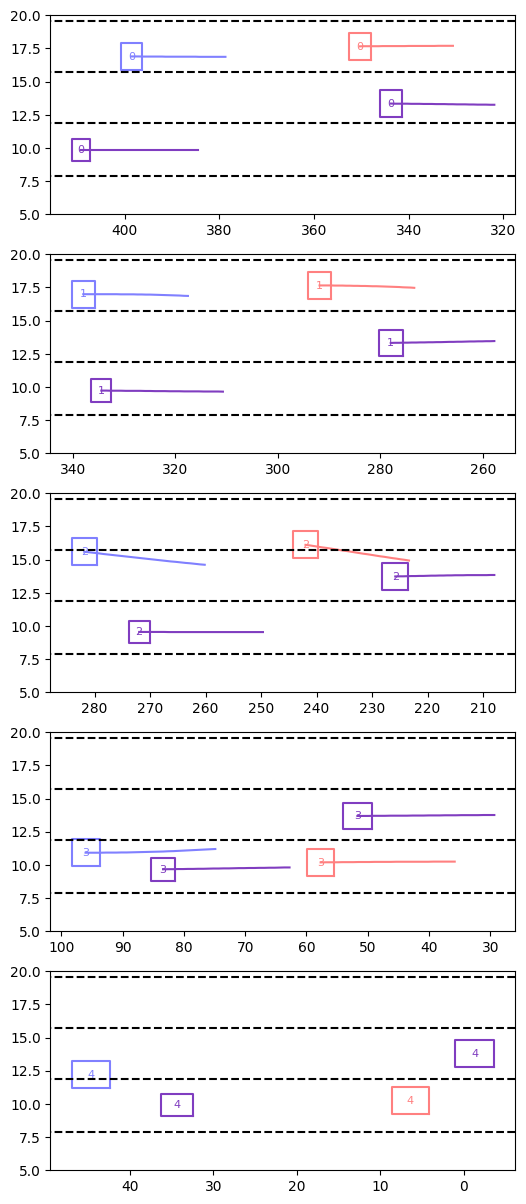

In [215]:
fig, axes = plt.subplots(len(pois), 1, figsize=(6, 3 * len(pois)))

F_FUT = 25

for i, p in enumerate(pois):
    
    cycle = color_cycler()
    color = next(cycle)['color']
    ax = axes[i]
    bb = ego['t'].get_bbox_at_frame(p)[0]
    c = bb.mean(axis=0)
    bb = np.vstack([bb, bb[0]])
    x = ego['t'].get_data_at_frame('x',p)
    y = ego['t'].get_data_at_frame('y',p)
    ax.plot(bb[:, 0], bb[:, 1], color=color)
    ax.text(c[0], c[1], str(i), fontsize=8, ha='center', va='center', color=color)

    if not i+1 == len(pois):
        ax.plot(ego['t'].get_data_between_frames('x', p, p+F_FUT) + ego['w2'], ego['t'].get_data_between_frames('y', p, p+F_FUT) + ego['h2'], color=color)


    for obj in objs:
        color = next(cycle)['color']
        bb = obj['t'].get_bbox_at_frame(p)[0]
        c = bb.mean(axis=0)
        bb = np.vstack([bb, bb[0]])
        x = obj['t'].get_data_at_frame('x',p)
        y = obj['t'].get_data_at_frame('y',p)
        ax.plot(bb[:, 0], bb[:, 1], color=color)
        ax.text(c[0], c[1], str(i), fontsize=8, ha='center', va='center', color=color)

        if not i+1 == len(pois):
            ax.plot(obj['t'].get_data_between_frames('x', p, p+F_FUT) + obj['w2'], obj['t'].get_data_between_frames('y', p, p+F_FUT) + obj['h2'], color=color)

    xlims = ax.get_xlim()
    print(xlims)
    for l in lanes:
        ax.plot(xlims, [l, l], 'k--')
    ax.set_xlim(xlims) # Somehow need to reset the limits

    # ax.set_aspect('equal')  # Keep aspect ratio
    ax.set_ylim([5, 20])
    if ego['t'].get_data('xVelocity')[0] < 0:
        ax.invert_xaxis()
    else:
        ax.invert_yaxis()
